# Plots for Target Enrichment Metrics, Probe Expansion, N Targets per cell

## Preprocessing
- Target enrichment metrics are calculated using Picard CollectHsMetrics

```bash
#!/bin/bash

# Create directories if they don't exist
mkdir -p hs_metrics

# Process TW1nt12k probe
for f in /home/tcheng/tcheng/Projects/RETrace/20210920_NovaSeq_HCT116_1nt12k_2nt24k/results_TW1nt12k_500targets_minqual0_minreads10/mapping/bam/*.sorted.bam; do
    fbname=$(basename "$f" .sorted.bam)
    echo "$fbname"

    picard CollectHsMetrics \
        --INPUT "$f" \
        --OUTPUT hs_metrics/"${fbname}"_hs_metrics_TW_hg38_1nt15-50bp_12472probes.txt \
        --BAIT_INTERVALS /home/tcheng/software/RETrace2/resources/picard_interval_list/hg38/RETrace.hg38.1nt15-50bp.12472probes.Picard.interval_list \
        --TARGET_INTERVALS /home/tcheng/software/RETrace2/resources/picard_interval_list/hg38/RETrace.hg38.1nt15-50bp.12472probes.Picard.interval_list || exit 1
done

# Process CA2nt24k probe
for f in /home/tcheng/tcheng/Projects/RETrace/20210920_NovaSeq_HCT116_1nt12k_2nt24k/results_CA2nt24k_500targets_minqual0_minreads10/mapping/bam/*.sorted.bam; do
    fbname=$(basename "$f" .sorted.bam)
    echo "$fbname"

    picard CollectHsMetrics \
        --INPUT "$f" \
        --OUTPUT hs_metrics/"${fbname}"_hs_metrics_CA_hg38_2-6nt_24000probes.txt \
        --BAIT_INTERVALS /home/tcheng/software/RETrace2/resources/picard_interval_list/hg38/RETrace.hg38.2-6nt.24000probes.Picard.interval_list \
        --TARGET_INTERVALS /home/tcheng/software/RETrace2/resources/picard_interval_list/hg38/RETrace.hg38.2-6nt.24000probes.Picard.interval_list || exit 1
done

```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

## Parameters

In [2]:
hs_path_dc = {'\nRETrace v1\n20210920':glob.glob("/home/tcheng/Projects/RETrace/20210920_NovaSeq_HCT116_1nt12k_2nt24k/target_enrichment/hs_metrics/*CA_hg38_2-6nt*.txt"),
              '\nRETrace v2\n20240319':glob.glob("/home/tcheng/Projects/RETrace/20240319_AVITI_RETrace2_3T3L1_Tree_Nextflow/target_enrichment/hs_metrics/*_1nt10-30bp*.txt")
}

## Read Table

In [3]:
def get_metric_df(path):
    '''Take the path of PiCard CollectHsMetrics ouput .txt file and generate a consie dataframe with most useful info'''

    text = pd.read_csv(path)
    metric = text.iloc[4,0].split("\t")
    result = text.iloc[5,0].split("\t")
    df = pd.DataFrame({'metric':metric, 'result':result})
    
    return(df)

In [4]:
# read raw output
hs_raw_dfs_dc = {k:[get_metric_df(p) for p in p_list] for k, p_list in hs_path_dc.items()}

# select most useful info: on bait, exclude target
hs_dfs_dc = {k:[df.iloc[np.r_[:13, 20:57],] for df in df_list] for k, df_list in hs_raw_dfs_dc.items()}

In [5]:
# look at one example output
hs_dfs_dc['\nRETrace v1\n20210920'][0]

,metric,result
0,BAIT_SET,RETrace
1,BAIT_TERRITORY,393536
2,BAIT_DESIGN_EFFICIENCY,1
3,ON_BAIT_BASES,98786624
4,NEAR_BAIT_BASES,247308761
5,OFF_BAIT_BASES,817909232
6,PCT_SELECTED_BASES,0.297332
7,PCT_OFF_BAIT,0.702668
8,ON_BAIT_VS_SELECTED,0.285432
9,MEAN_BAIT_COVERAGE,251.023093


# Plot % on target

In [6]:
# build df for violin plot
probe_ls = []
on_target = []

for k, df_list in hs_dfs_dc.items():
    for df in df_list:
        probe_ls.append(k)
        on_target.append(round(float(df.iloc[6,1])*100, 2))
        
data = pd.DataFrame({'probe':probe_ls, 'on_target': on_target})
data.head()

,probe,on_target
0,\nRETrace v1\n20210920,29.73
1,\nRETrace v1\n20210920,38.30
2,\nRETrace v1\n20210920,29.99
3,\nRETrace v1\n20210920,28.53
4,\nRETrace v1\n20210920,29.50


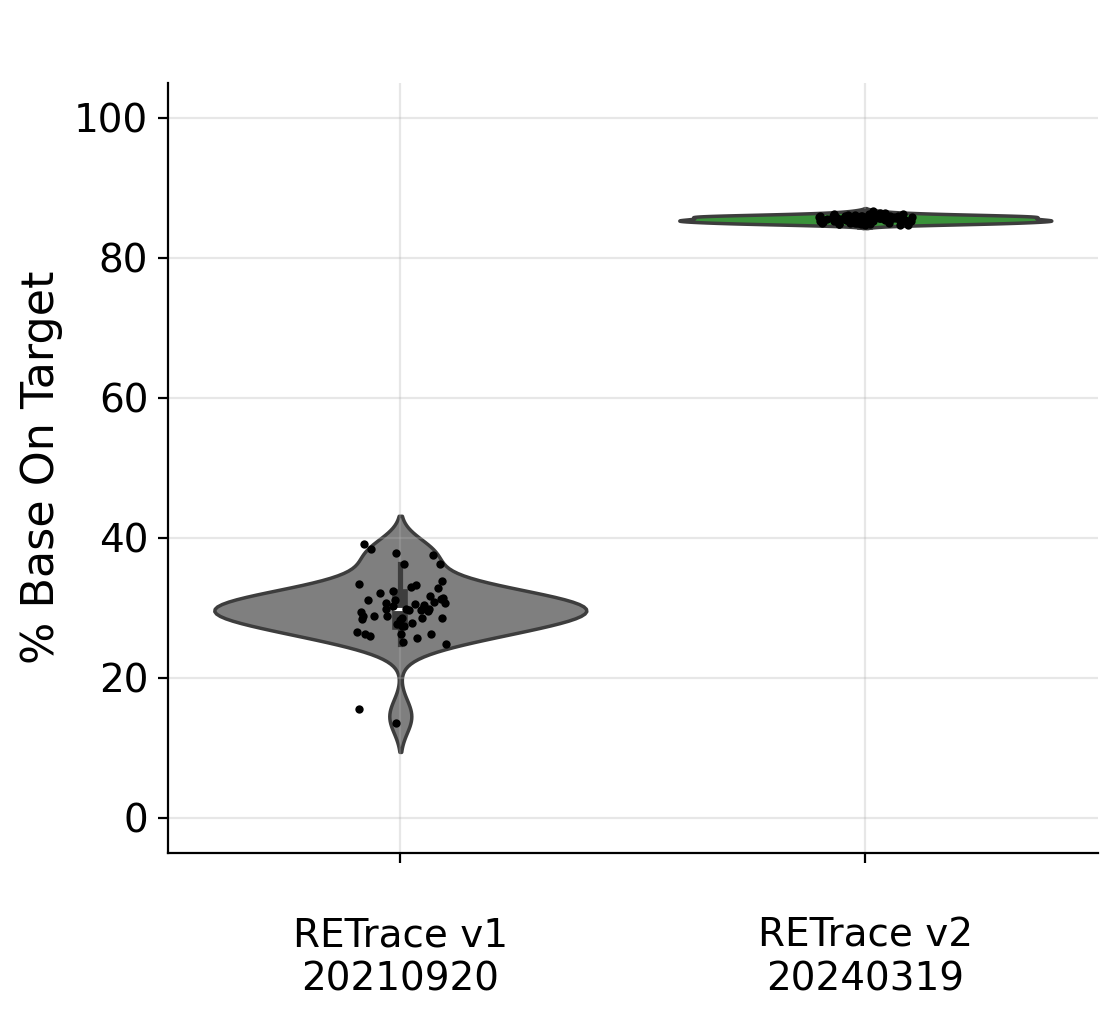

In [7]:
fig, ax = plt.subplots(figsize=(6,5), dpi=200)

sns.violinplot(x='probe', y='on_target', data=data, hue='probe', palette=['tab:gray', 'tab:green'])
sns.stripplot(x="probe", y="on_target", data=data, color="black", ax=ax, size=3)

ax.set_xlabel("")
ax.set_title(" ", fontsize=22)
ax.set_ylabel('% Base On Target', fontsize=16)

ax.tick_params(axis='both', labelsize=14)

# Get unique values from 'probe' column
unique_probes = data['probe'].unique()

# Set the tick locations and labels
ax.set_xticks(range(len(unique_probes)))

ax.grid(True, alpha=0.3)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_ylim(-5,105)

plt.show()

## Stats

In [8]:
data.groupby(["probe"]).describe().transpose()

probe            \nRETrace v1\n20210920  \nRETrace v2\n20240319
on_target count               54.000000               72.000000
          mean                29.760926               85.480556
          std                  4.520196                0.471915
          min                 13.450000               84.600000
          25%                 27.877500               85.150000
          50%                 29.740000               85.440000
          75%                 31.565000               85.855000
          max                 39.040000               86.660000

# Plot % Target covered at different depth

In [9]:
# build df for violin plot
probe_ls = []
perc_target = []

for k, df_list in hs_dfs_dc.items():
    for df in df_list:
        probe_ls += [k] * 5
        df.index = df.metric
        perc_target += [round(float(x)*100, 1) for x in df.loc[["PCT_TARGET_BASES_1X", "PCT_TARGET_BASES_2X", "PCT_TARGET_BASES_10X",
                                                     "PCT_TARGET_BASES_30X", "PCT_TARGET_BASES_50X"],"result"]] 

data2 = pd.DataFrame({'probe': probe_ls,
                     'coverage_depth': ['1X', '2X', '10X', '30X', '50X']*int(len(probe_ls)/5),
                     'perc_target': perc_target})
data2.head()

,probe,coverage_depth,perc_target
0,\nRETrace v1\n20210920,1X,38.2
1,\nRETrace v1\n20210920,2X,29.7
2,\nRETrace v1\n20210920,10X,16.9
3,\nRETrace v1\n20210920,30X,12.6
4,\nRETrace v1\n20210920,50X,11.3


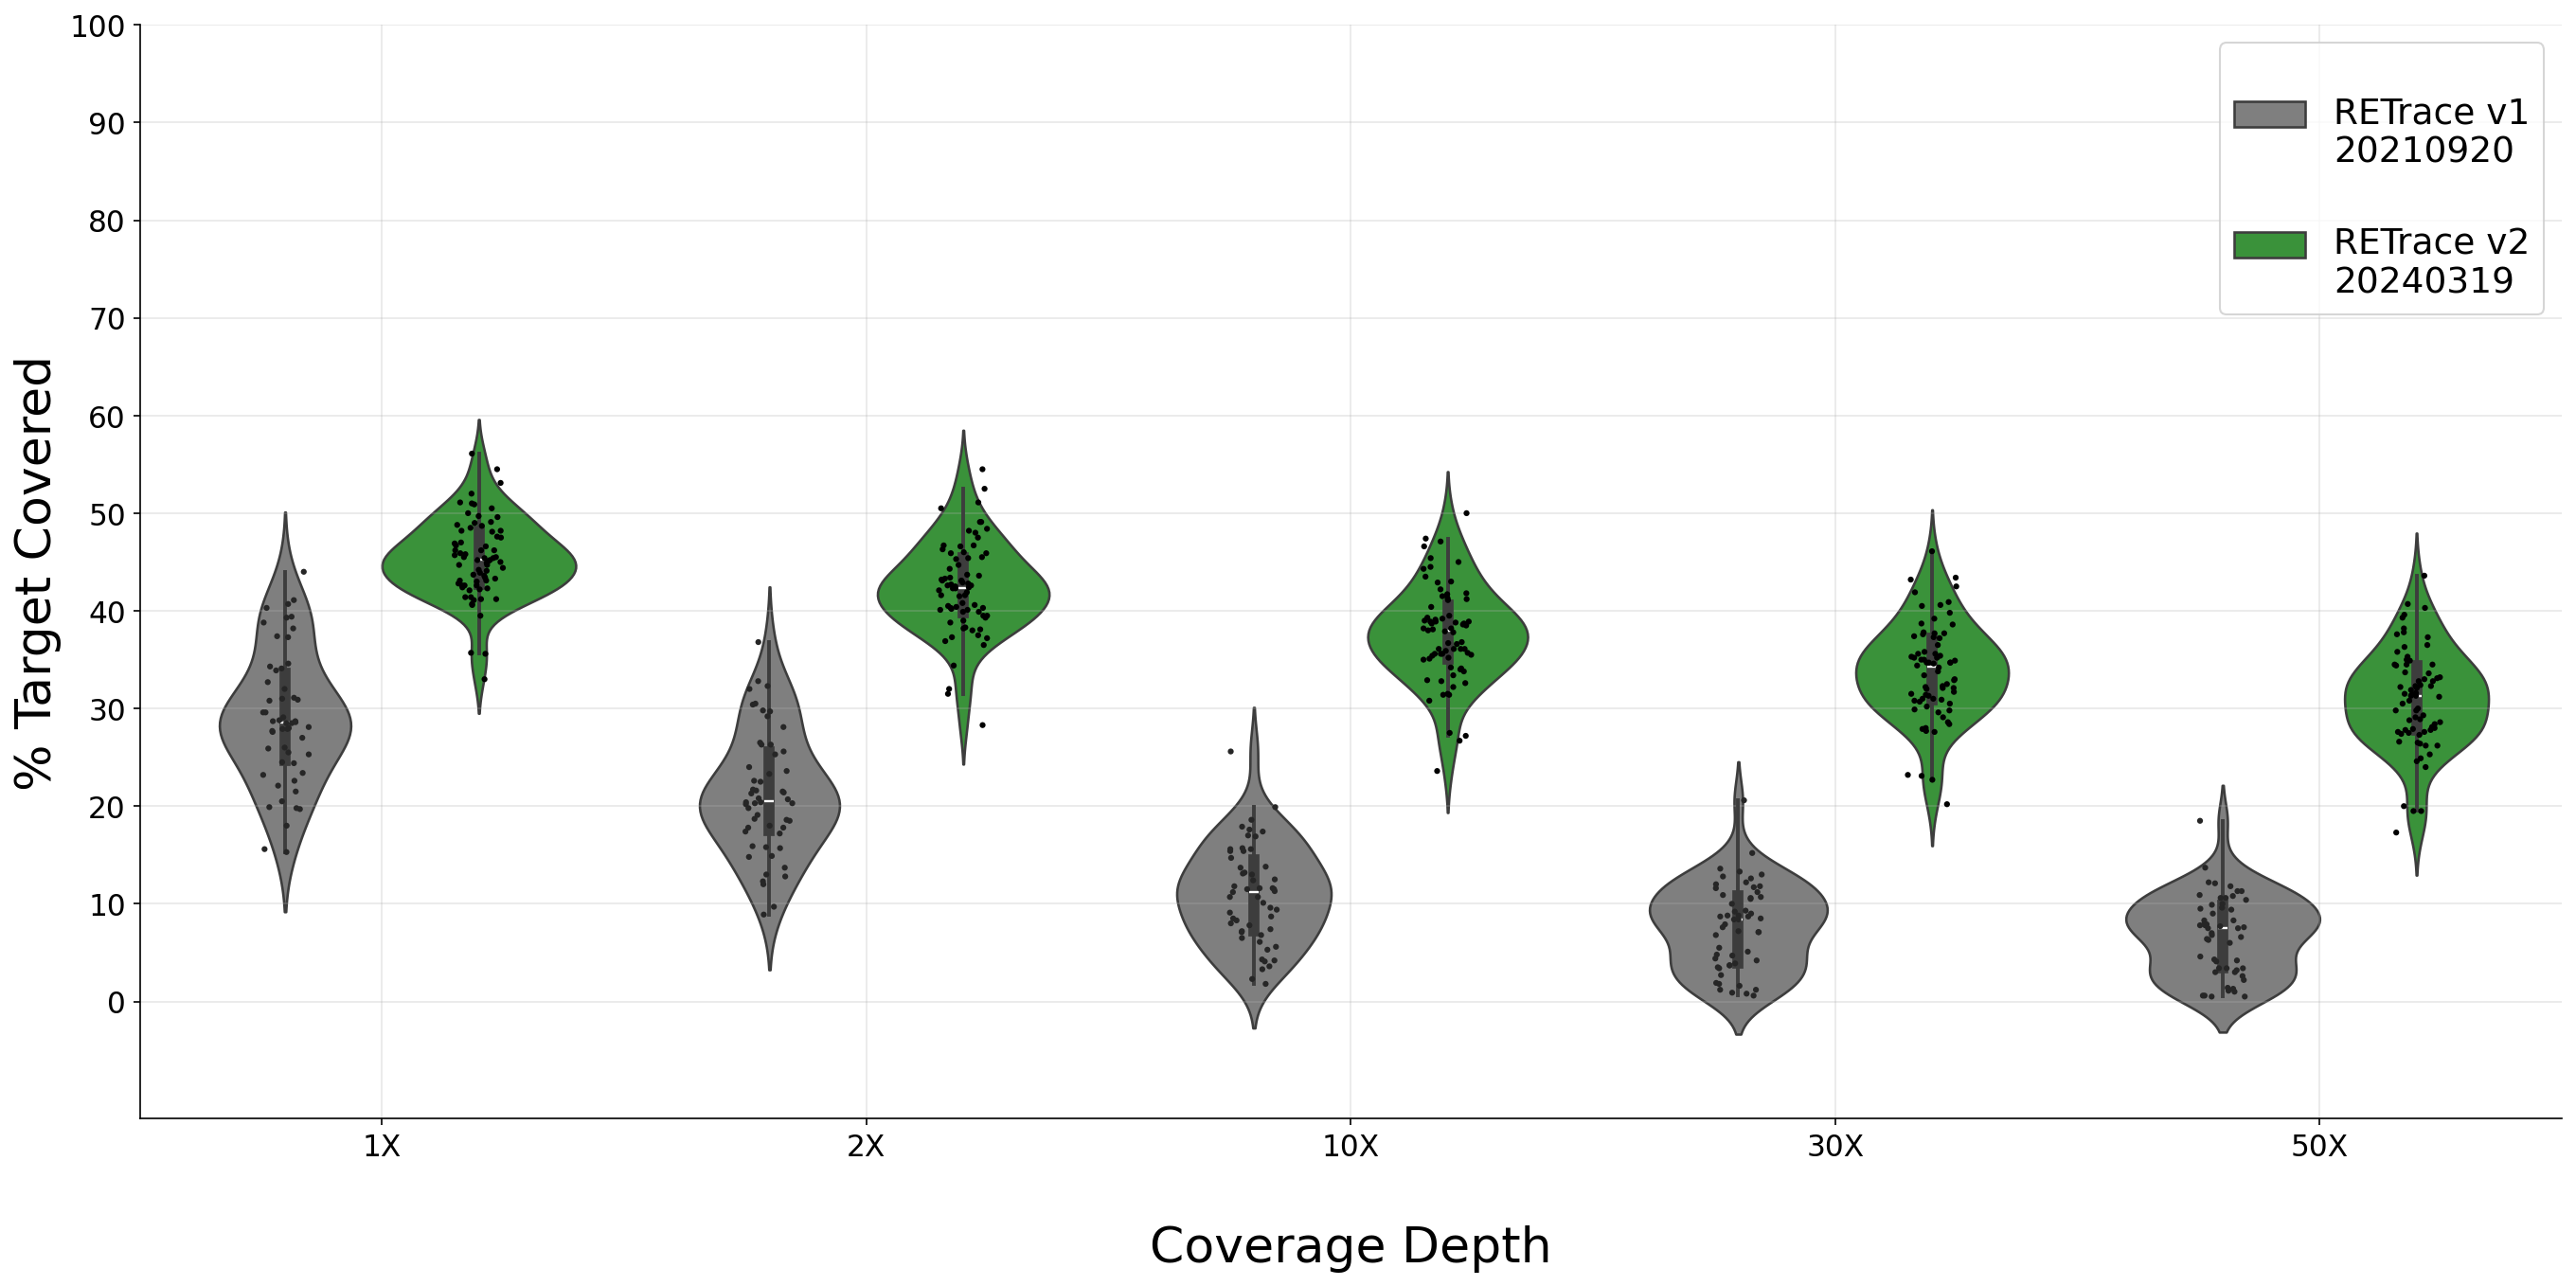

In [10]:
fig, ax = plt.subplots(figsize=(22,10), dpi=150)

sns.violinplot(x='coverage_depth', y='perc_target', data=data2, hue='probe', palette=['tab:gray', 'tab:green'])
sns.stripplot(x='coverage_depth', y='perc_target', data=data2, hue='probe', palette='dark:black', size=3, dodge=True)

ax.set_title("", fontsize=25)
ax.set_xlabel("\nCoverage Depth", fontsize=25)
ax.set_ylabel('% Target Covered', fontsize=25)
ax.tick_params(axis='both', labelsize=15)

ax.grid(True, alpha=0.3)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_ylim(-12,100)
ax.set_yticks(np.arange(0,101,10))

# remove legend label for dots
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], fontsize=18)


plt.show()

## Stats

In [11]:
data2.groupby(["coverage_depth", "probe"]).describe()

perc_target                             \
                                            count       mean       std   min   
coverage_depth probe                                                           
10X            \nRETrace v1\n20210920        54.0  10.962963  5.011056   1.8   
               \nRETrace v2\n20240319        72.0  37.561111  5.000494  23.6   
1X             \nRETrace v1\n20210920        54.0  29.062963  6.786899  15.3   
               \nRETrace v2\n20240319        72.0  45.316667  4.105647  33.0   
2X             \nRETrace v1\n20210920        54.0  21.307407  6.278080   8.9   
               \nRETrace v2\n20240319        72.0  42.316667  4.693598  28.3   
30X            \nRETrace v1\n20210920        54.0   7.692593  4.376690   0.6   
               \nRETrace v2\n20240319        72.0  33.787500  4.994530  20.2   
50X            \nRETrace v1\n20210920        54.0   6.803704  4.035735   0.5   
               \nRETrace v2\n20240319        72.0  30.941667  5.129170  17.3   

                                                                    
                                          25%    50%     75%   max  
coverage_depth probe                                                
10X            \nRETrace v1\n20210920   7.250  11.25  14.475  25.6  
               \nRETrace v2\n20240319  35.075  37.95  40.575  50.0  
1X             \nRETrace v1\n20210920  24.700  28.55  33.600  44.0  
               \nRETrace v2\n20240319  42.750  45.20  48.125  56.1  
2X             \nRETrace v1\n20210920  17.500  20.55  25.525  36.8  
               \nRETrace v2\n20240319  39.800  42.35  45.425  54.5  
30X            \nRETrace v1\n20210920   3.975   8.40  10.850  20.6  
               \nRETrace v2\n20240319  30.875  34.30  37.225  46.1  
50X            \nRETrace v1\n20210920   3.400   7.50   9.825  18.5  
               \nRETrace v2\n20240319  27.750  31.30  34.425  43.6

In [12]:
data3 = data2.query("coverage_depth == '10X'")
data3.head()

,probe,coverage_depth,perc_target
2,\nRETrace v1\n20210920,10X,16.9
7,\nRETrace v1\n20210920,10X,13.7
12,\nRETrace v1\n20210920,10X,14.7
17,\nRETrace v1\n20210920,10X,6.1
22,\nRETrace v1\n20210920,10X,11.2


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


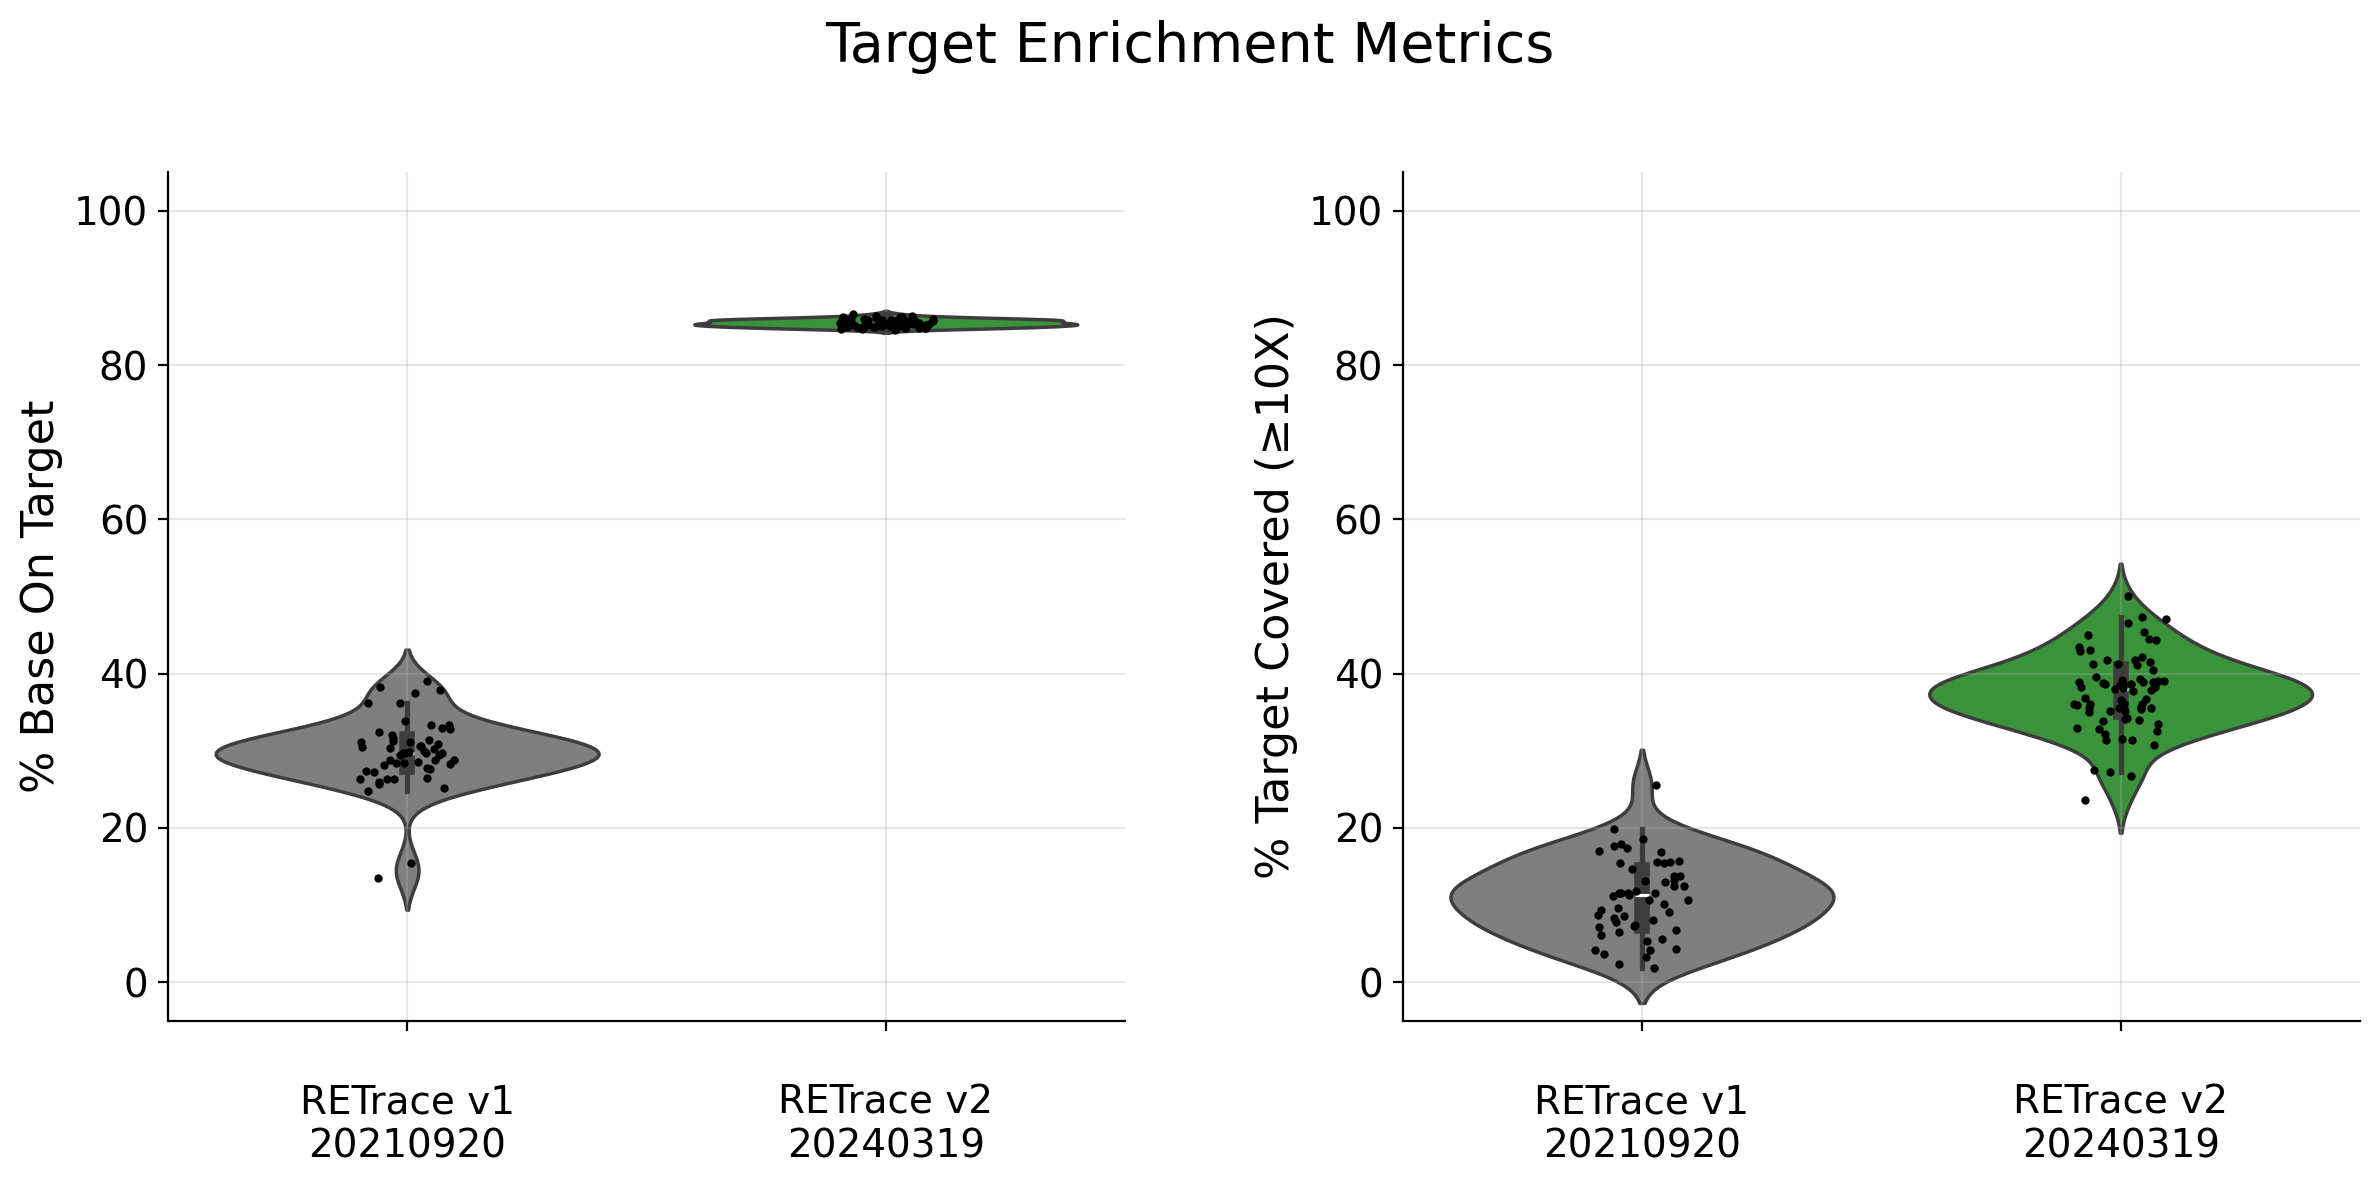

In [13]:
# Combined Plot - Side by Side
fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=200)
fig.suptitle('Target Enrichment Metrics\n', fontsize=20)

# Left plot: % Base On Target
sns.violinplot(x='probe', y='on_target', data=data, hue='probe', palette=['tab:gray', 'tab:green'], ax=axes[0])
sns.stripplot(x="probe", y="on_target", data=data, color="black", ax=axes[0], size=3)

axes[0].set_xlabel("")
axes[0].set_ylabel('% Base On Target', fontsize=16)
axes[0].tick_params(axis='both', labelsize=14)

# Get unique values from 'probe' column
unique_probes = data['probe'].unique()
axes[0].set_xticks(range(len(unique_probes)))

axes[0].grid(True, alpha=0.3)
axes[0].spines['right'].set_visible(False)
axes[0].spines['top'].set_visible(False)
axes[0].set_ylim(-5, 105)

# Right plot: % Target Covered at 10X
sns.violinplot(x='probe', y='perc_target', data=data3, hue='probe', palette=['tab:gray', 'tab:green'], ax=axes[1])
sns.stripplot(x="probe", y="perc_target", data=data3, color="black", ax=axes[1], size=3)

axes[1].set_xlabel("")
axes[1].set_ylabel('\n\n% Target Covered (≥10X)', fontsize=16)
axes[1].tick_params(axis='both', labelsize=14)

axes[1].set_xticks(range(len(unique_probes)))

axes[1].grid(True, alpha=0.3)
axes[1].spines['right'].set_visible(False)
axes[1].spines['top'].set_visible(False)
axes[1].set_ylim(-5, 105)

# Remove legends (since hue=probe is redundant with x=probe)
axes[0].legend().set_visible(False)
axes[1].legend().set_visible(False)

plt.tight_layout()
plt.savefig("Target_enrichment_metrics.pdf")
plt.show()


# Plot Probe Info

In [14]:
def count_lines(filename):
    with open(filename, 'r') as f:
        return sum(1 for line in f)

# N target can be calculated from target bed file
retrace1_n_targets = count_lines('/home/tcheng/software/RETrace2/resources/targets/hg38/RETrace.hg38.2-6nt.24000probes.bed')
retrace2_n_targets = count_lines('/home/tcheng/software/RETrace2/resources/targets/mm39/RETrace2.mm39.1nt10-30bp.92460targets169818probes.bed')

print(retrace1_n_targets, retrace2_n_targets)

11328 92460


In [15]:
probe_data = pd.DataFrame({'name':['\nRETrace v1\nDi- to Hexanucleotide', '\nRETrace v2\nHomopolymer'],
                           'n_target': [11328, 92460],
                           'n_probe': [24000, 169818]})

probe_data

,name,n_target,n_probe
0,\nRETrace v1\nDi- to Hexanucleotide,11328,24000
1,\nRETrace v2\nHomopolymer,92460,169818


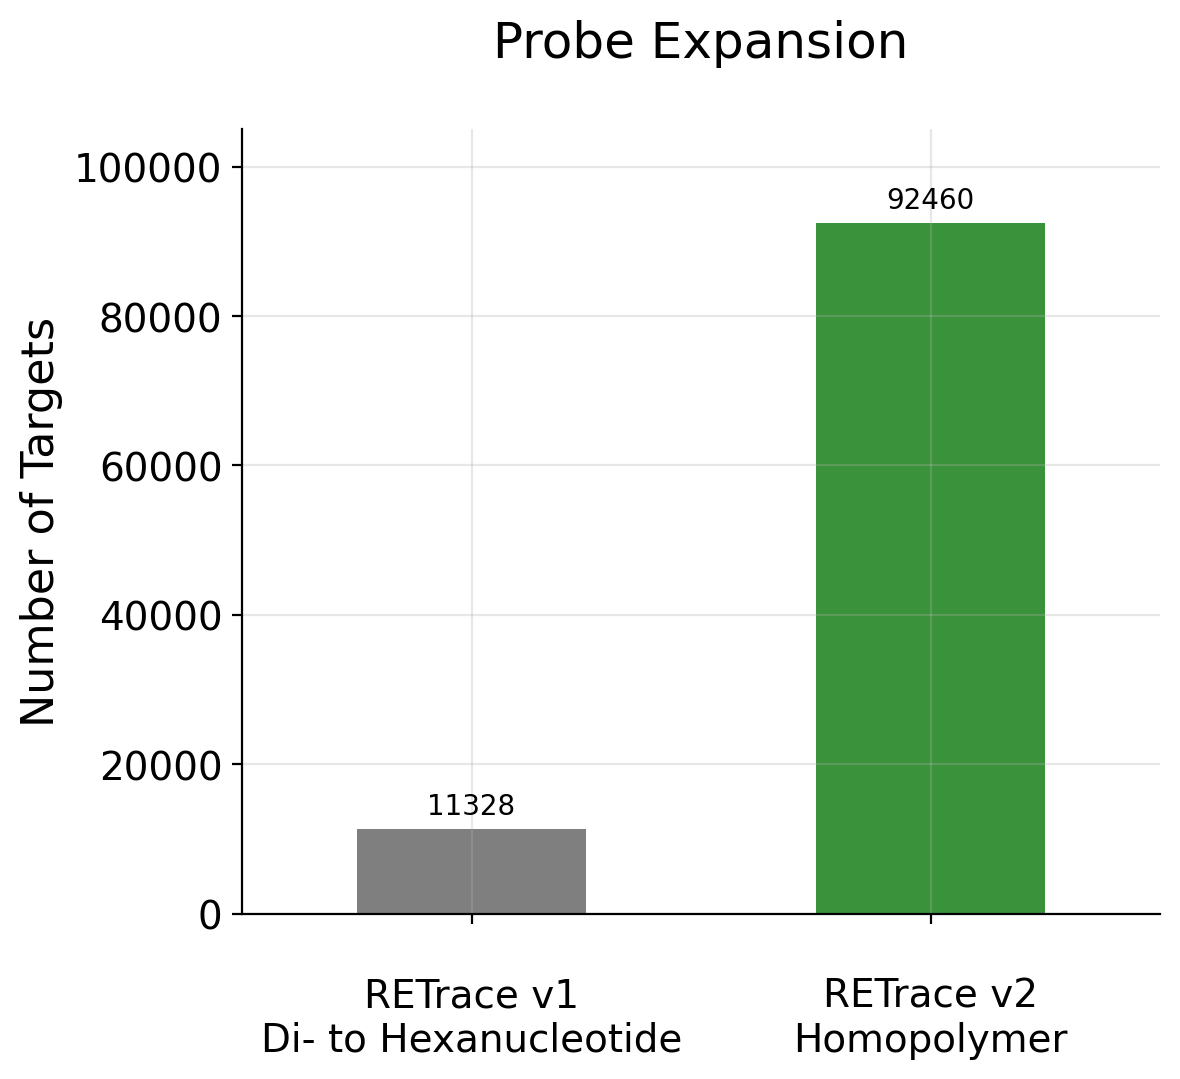

In [16]:
fig, ax = plt.subplots(figsize=(6,5.5), dpi=200)

# plot n target
sns.barplot(data=probe_data, x='name', y='n_target', hue='name',palette=['tab:gray', 'tab:green'], width=0.5)

ax.set_title('Probe Expansion\n', fontsize=18)
ax.set_ylabel('Number of Targets', fontsize=16)
ax.tick_params(axis='both', labelsize=14)

ax.set_ylim(0,1e5+5000)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel('')
ax.grid(True, alpha=0.3)

# add text
for i, n in enumerate(probe_data.n_target):
    ax.text(i, n+2000, n, ha='center')

plt.tight_layout()
plt.savefig("Probe_expansion.pdf")
plt.show()

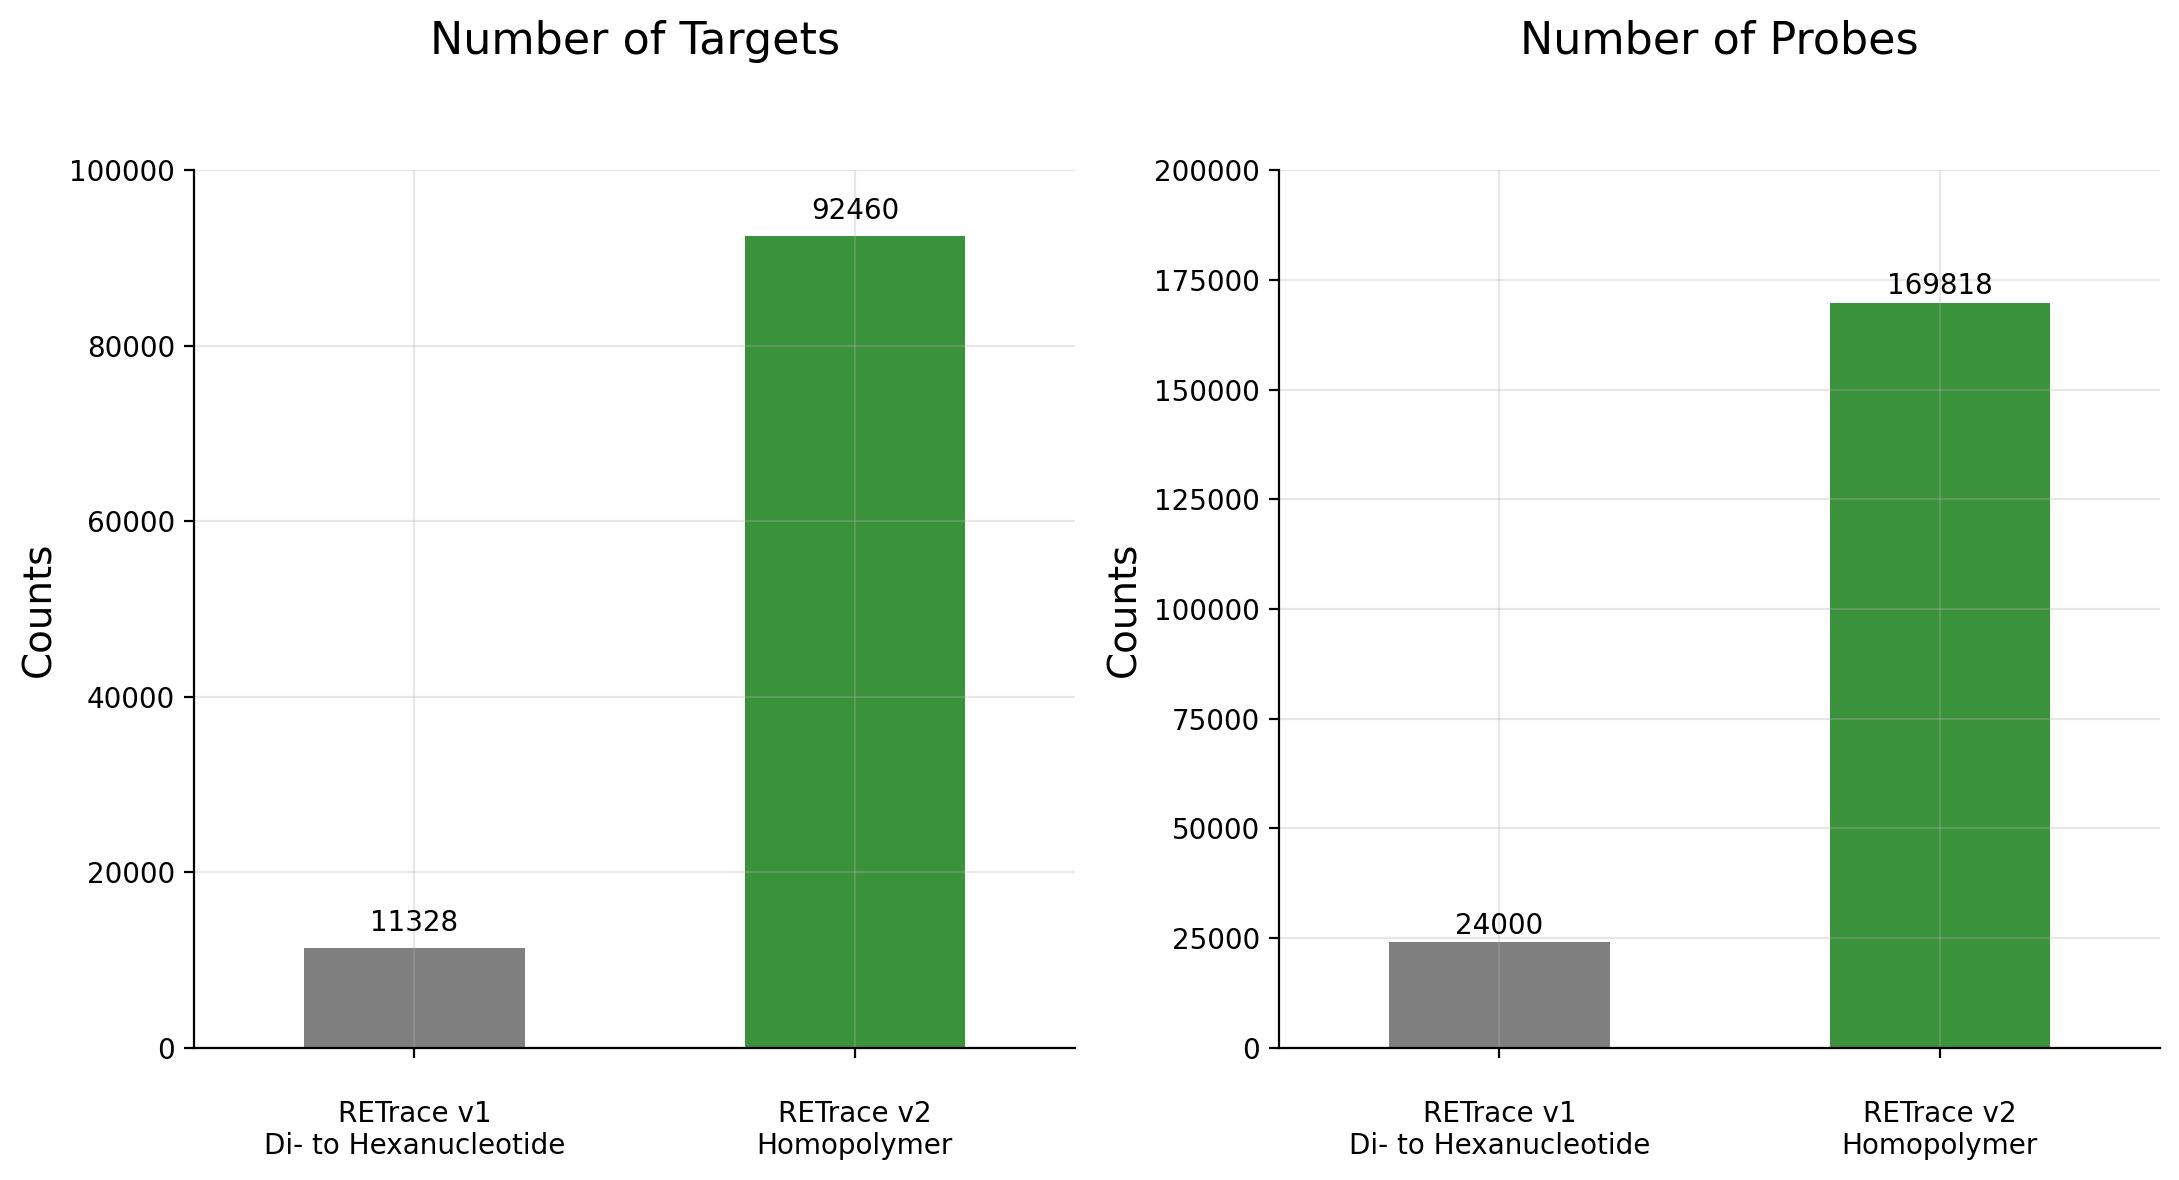

In [17]:
fig, ax = plt.subplots(figsize=(11,6), dpi=200, ncols=2)

# plot n target
sns.barplot(data=probe_data, x='name', y='n_target', ax=ax[0], hue='name', palette=['tab:gray', 'tab:green'], width=0.5)
# plot n probe
sns.barplot(data=probe_data, x='name', y='n_probe', ax=ax[1], hue='name', palette=['tab:gray', 'tab:green'], width=0.5)


ax[0].set_title('Number of Targets\n\n', fontsize=16)
ax[1].set_title('Number of Probes\n\n', fontsize=16)
ax[0].set_ylabel('Counts', fontsize=14)
ax[1].set_ylabel('Counts', fontsize=14)


for a in ax:
    a.set_ylim(0,2e5)
    a.spines['right'].set_visible(False)
    a.spines['top'].set_visible(False)
    a.set_xlabel('')
    a.grid(True, alpha=0.3)

ax[0].set_ylim(0,1e5)

# add text
for i, n in enumerate(probe_data.n_target):
    ax[0].text(i, n+2000, n, ha='center')
for i, n in enumerate(probe_data.n_probe):
    ax[1].text(i, n+2000, n, ha='center')

plt.tight_layout()
plt.show()

# Plot N target per cell
- We use RETrace v1 20210920 and RETrace v2 20240319 library as examples

In [18]:
# read RETrace v1 20210920 stats
stats_data_v1 = pd.read_csv('/home/tcheng/tcheng/Projects/RETrace/20210920_NovaSeq_HCT116_1nt12k_2nt24k/results_CA2nt24k_500targets_minqual0_minreads10/stats/sample_stats.tsv', sep='\t')
stats_data_v1['group'] = ['\nRETrace v1\n20210920'] * stats_data_v1.shape[0]

In [19]:
# read RETrace v2 20240319 stats
stats_data_v2 = pd.read_csv('/home/tcheng/Projects/RETrace/20240319_AVITI_RETrace2_3T3L1_Tree_Nextflow/results_10000targets_3000cpgs_minqual0.9/stats/sample_stats.tsv', sep='\t')
stats_data_v2['group'] = ['\nRETrace v2\n20240319'] * stats_data_v2.shape[0]

In [20]:
# combine stats data
stats_data = pd.concat([stats_data_v1, stats_data_v2])
stats_data.head()

,sample_id,ms_targets_with_min_reads,cpg_count,pass,group
0,2-1-C4_3-7-G7_Plate2-1B,1232,0,True,\nRETrace v1\n20210920
1,2-1-C4_3-7-G7_Plate2-1C,1229,0,True,\nRETrace v1\n20210920
2,2-1-C4_3-7-G7_Plate2-1D,1052,0,True,\nRETrace v1\n20210920
3,2-1-C4_3-7-G7_Plate2-1E,1860,0,True,\nRETrace v1\n20210920
4,2-1-C4_3-7-G7_Plate2-1F,247,0,False,\nRETrace v1\n20210920


In [21]:
# filter for passing cells
stats_data = stats_data[stats_data['pass'] == True]


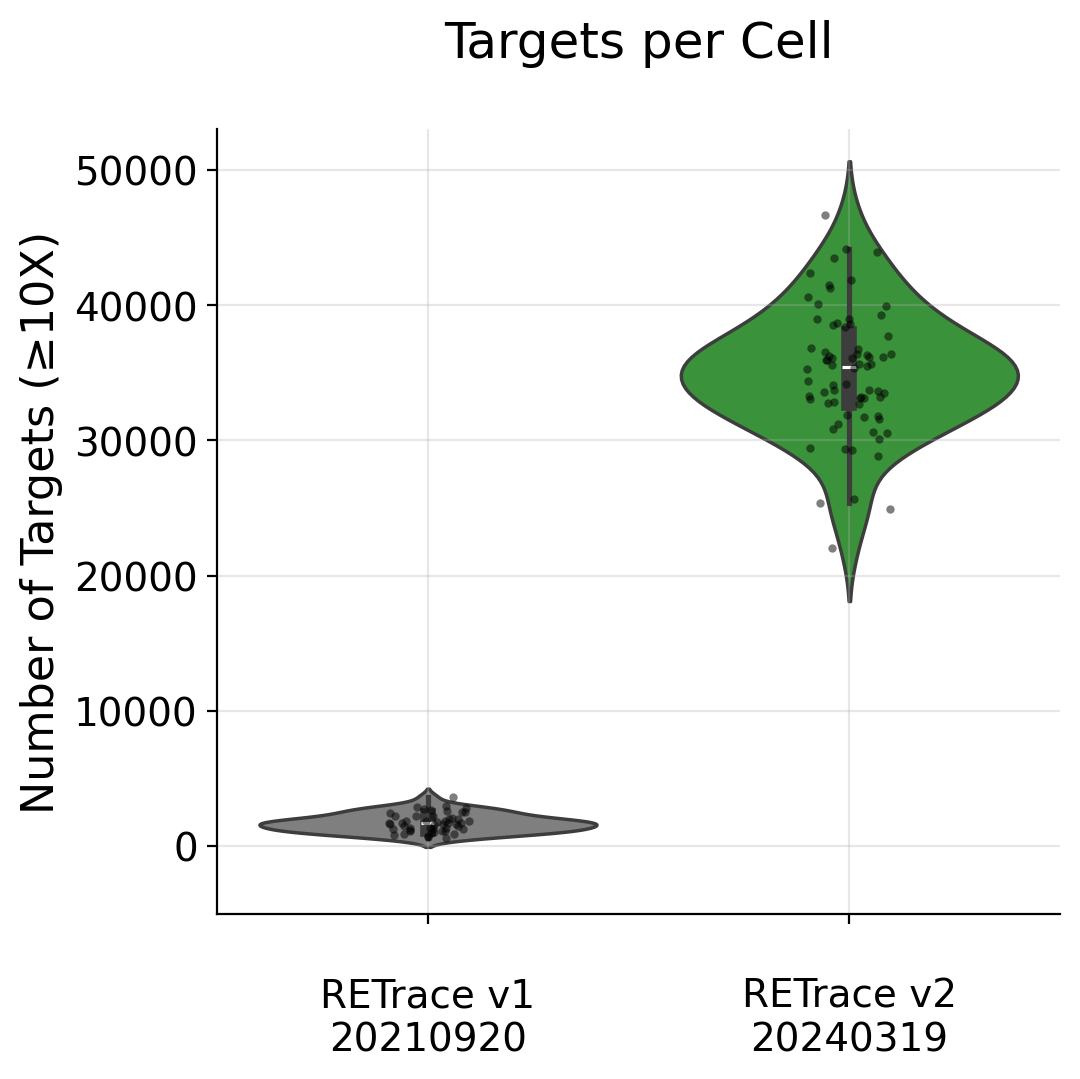

In [22]:
fig, ax = plt.subplots(figsize=(5.5,5.5), dpi=200)

sns.violinplot(x='group', y='ms_targets_with_min_reads', data=stats_data, hue='group', palette=['tab:gray', 'tab:green'])
sns.stripplot(x="group", y="ms_targets_with_min_reads", data=stats_data, color="black", ax=ax, size=3, alpha=0.5)

ax.set_xlabel("")
ax.set_title("Targets per Cell\n", fontsize=18)
ax.set_ylabel('Number of Targets (≥10X)', fontsize=16)
ax.tick_params(axis='both', labelsize=14)

ax.set_ylim(-5000, 53000)
ax.grid(True, alpha=0.3)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig("Ntargets_per_cell.pdf")
plt.show()

In [23]:
stats_data.loc[:, ["group", "ms_targets_with_min_reads"]].groupby(["group"]).describe()

ms_targets_with_min_reads                             \
                                           count          mean          std   
group                                                                         
\nRETrace v1\n20210920                      49.0   1724.265306   690.418978   
\nRETrace v2\n20240319                      72.0  35038.486111  4648.216878   

                                                                     
                            min      25%      50%      75%      max  
group                                                                
\nRETrace v1\n20210920    566.0   1229.0   1662.0   2204.0   3602.0  
\nRETrace v2\n20240319  22062.0  32758.5  35404.0  37891.5  46681.0

In [24]:
stats_data.loc[:, ["group", "ms_targets_with_min_reads"]].groupby(["group"]).median()

,ms_targets_with_min_reads
group,
\nRETrace v1\n20210920,1662.0
\nRETrace v2\n20240319,35404.0


# Supplementary Table 3: Per Cell Stats
- Here we inlcude the code to generate the per-cell statistics supplementary table 3, including both the homopolymer and di-to-hexanucleotide libraries.

In [25]:
import os
import glob

def parse_samtools_stats(stats_file):
    """
    Parse a samtools stats file to extract total reads and alignment rate.
    
    Returns a dictionary with:
    - total_reads: Total number of reads
    - alignment_rate: Percentage of reads mapped
    """
    with open(stats_file, 'r') as f:
        lines = f.readlines()
    
    # Line 1: total reads (e.g., "33255366 + 0 in total (QC-passed reads + QC-failed reads)")
    total_reads_line = lines[0].strip()
    total_reads = int(total_reads_line.split()[0])
    
    # Line 7: mapped reads with percentage (e.g., "33211939 + 0 mapped (99.87% : N/A)")
    mapped_line = lines[6].strip()  # 0-indexed, so line 7 is index 6
    # Extract percentage from parentheses
    import re
    alignment_rate = float(re.search(r'\((\d+\.\d+)%', mapped_line).group(1))
    
    return {
        'total_reads': total_reads,
        'alignment_rate': alignment_rate
    }

# Process CA2nt24k library (di-to-hexanucleotide)
stats_dir_CA2nt = '/home/tcheng/tcheng/Projects/RETrace/20210920_NovaSeq_HCT116_1nt12k_2nt24k/results_CA2nt24k_500targets_minqual0_minreads10/mapping/bam'
stats_files_CA2nt = glob.glob(os.path.join(stats_dir_CA2nt, '*.stats'))

print(f"Found {len(stats_files_CA2nt)} stats files for CA2nt24k")

mapping_data_CA2nt = []
for stats_file in stats_files_CA2nt:
    sample_id = os.path.basename(stats_file).replace('.stats', '')
    try:
        stats = parse_samtools_stats(stats_file)
        stats['sample_id'] = sample_id
        stats['target_type'] = 'di-to-hexanucleotide'
        mapping_data_CA2nt.append(stats)
    except Exception as e:
        print(f"Error parsing {sample_id}: {e}")

# Process TW1nt12k library (homopolymer)
stats_dir_TW1nt = '/home/tcheng/tcheng/Projects/RETrace/20210920_NovaSeq_HCT116_1nt12k_2nt24k/results_TW1nt12k_500targets_minqual0_minreads10/mapping/bam'
stats_files_TW1nt = glob.glob(os.path.join(stats_dir_TW1nt, '*.stats'))

print(f"Found {len(stats_files_TW1nt)} stats files for TW1nt12k")

mapping_data_TW1nt = []
for stats_file in stats_files_TW1nt:
    sample_id = os.path.basename(stats_file).replace('.stats', '')
    try:
        stats = parse_samtools_stats(stats_file)
        stats['sample_id'] = sample_id
        stats['target_type'] = 'homopolymer_10to15bp'
        mapping_data_TW1nt.append(stats)
    except Exception as e:
        print(f"Error parsing {sample_id}: {e}")

# Combine both datasets
mapping_data_all = mapping_data_CA2nt + mapping_data_TW1nt
df_mapping = pd.DataFrame(mapping_data_all)

print(f"\nSuccessfully parsed {len(df_mapping)} total samples")
print(f"  - CA2nt24k (di-to-hexanucleotide): {len(mapping_data_CA2nt)}")
print(f"  - TW1nt12k (homopolymer_10to15bp): {len(mapping_data_TW1nt)}")
df_mapping.head()


Found 54 stats files for CA2nt24k
Found 54 stats files for TW1nt12k

Successfully parsed 108 total samples
  - CA2nt24k (di-to-hexanucleotide): 54
  - TW1nt12k (homopolymer_10to15bp): 54


,total_reads,alignment_rate,sample_id,target_type
0,6017863,99.74,2-1-C4_3-7-G7_Plate2-2B,di-to-hexanucleotide
1,9045003,99.75,2-1-F7_3-3-B9_Plate2-4E,di-to-hexanucleotide
2,10868713,99.81,2-1-C4_3-7-G7_Plate2-3B,di-to-hexanucleotide
3,8697796,99.47,2-1-H9_3-4-D8_Plate2-8D,di-to-hexanucleotide
4,6956443,99.73,2-1-F7_3-3-B9_Plate2-6E,di-to-hexanucleotide


In [26]:
# Load samplesheets to get group (clone) information for both libraries
samplesheet_CA2nt = '/home/tcheng/tcheng/Projects/RETrace/20210920_NovaSeq_HCT116_1nt12k_2nt24k/20210920_HCT116_2-6nt24k_samplesheet.csv'
samplesheet_TW1nt = '/home/tcheng/tcheng/Projects/RETrace/20210920_NovaSeq_HCT116_1nt12k_2nt24k/20210920_HCT116_1nt12k_samplesheet.csv'

df_samplesheet_CA2nt = pd.read_csv(samplesheet_CA2nt)
df_samplesheet_TW1nt = pd.read_csv(samplesheet_TW1nt)

# Combine samplesheets
df_samplesheet = pd.concat([df_samplesheet_CA2nt, df_samplesheet_TW1nt])

# Read sample stats from both libraries
df_stats_CA2nt = pd.read_csv('/home/tcheng/tcheng/Projects/RETrace/20210920_NovaSeq_HCT116_1nt12k_2nt24k/results_CA2nt24k_500targets_minqual0_minreads10/stats/sample_stats.tsv', sep='\t')
df_stats_TW1nt = pd.read_csv('/home/tcheng/tcheng/Projects/RETrace/20210920_NovaSeq_HCT116_1nt12k_2nt24k/results_TW1nt12k_500targets_minqual0_minreads10/stats/sample_stats.tsv', sep='\t')

# Combine stats
df_stats = pd.concat([df_stats_CA2nt, df_stats_TW1nt])

# Merge mapping data with samplesheet and sample stats
df_merged = df_mapping.merge(
    df_samplesheet[['sample_id', 'group']], 
    on='sample_id', how='left'
).merge(
    df_stats[['sample_id', 'ms_targets_with_min_reads', 'pass']], 
    on='sample_id', how='left'
)

# Create per-cell statistics table with Clone, Library_Date, and Target_Type columns
supplementary_table = pd.DataFrame({
    'Cell_ID': df_merged['sample_id'],
    'Clone': df_merged['group'],
    'Library_Date': '20210920',  # All cells from this library date
    'Target_Type': df_merged['target_type'],
    'QC_Pass': df_merged['pass'],
    'MS_Total_Reads': df_merged['total_reads'],
    'MS_Alignment_Rate_Percent': df_merged['alignment_rate'],
    'MS_Targets_10X': df_merged['ms_targets_with_min_reads']
})

# Sort: passing cells first, then by Target_Type, Clone, and Cell ID
supplementary_table = supplementary_table.sort_values(
    ['QC_Pass', 'Target_Type', 'Clone', 'Cell_ID'], ascending=[False, True, True, True]
).reset_index(drop=True)

n_pass = supplementary_table['QC_Pass'].sum()
n_fail = len(supplementary_table) - n_pass
print(f"Per-cell statistics table: {len(supplementary_table)} total cells ({n_pass} pass, {n_fail} fail QC)")
print(f"\nBreakdown by target type:")
print(supplementary_table.groupby(['Target_Type', 'QC_Pass']).size())
print(f"\nPassing samples summary:")
print(supplementary_table[supplementary_table['QC_Pass'] == True][['MS_Total_Reads', 'MS_Alignment_Rate_Percent', 'MS_Targets_10X']].describe())

supplementary_table.head(10)


Per-cell statistics table: 108 total cells (83 pass, 25 fail QC)

Breakdown by target type:
Target_Type           QC_Pass
di-to-hexanucleotide  False       5
                      True       49
homopolymer_10to15bp  False      20
                      True       34
dtype: int64

Passing samples summary:
       MS_Total_Reads  MS_Alignment_Rate_Percent  MS_Targets_10X
count    8.300000e+01                  83.000000       83.000000
mean     8.113116e+06                  99.581446     1313.891566
std      3.626731e+06                   0.541502      732.244861
min      2.598817e+06                  95.280000      506.000000
25%      5.431490e+06                  99.640000      726.000000
50%      7.312786e+06                  99.700000     1085.000000
75%      9.996145e+06                  99.750000     1767.500000
max      1.869434e+07                  99.850000     3602.000000


,Cell_ID,Clone,Library_Date,Target_Type,QC_Pass,MS_Total_Reads,MS_Alignment_Rate_Percent,MS_Targets_10X
0,2-1-C4_3-7-G7_Plate2-1B,2-1-C4_3-7-G7,20210920,di-to-hexanucleotide,True,5924407,99.58,1232
1,2-1-C4_3-7-G7_Plate2-1C,2-1-C4_3-7-G7,20210920,di-to-hexanucleotide,True,6968149,99.61,1229
2,2-1-C4_3-7-G7_Plate2-1D,2-1-C4_3-7-G7,20210920,di-to-hexanucleotide,True,5487605,99.46,1052
3,2-1-C4_3-7-G7_Plate2-1E,2-1-C4_3-7-G7,20210920,di-to-hexanucleotide,True,8734012,99.75,1860
4,2-1-C4_3-7-G7_Plate2-2B,2-1-C4_3-7-G7,20210920,di-to-hexanucleotide,True,6017863,99.74,2013
5,2-1-C4_3-7-G7_Plate2-2C,2-1-C4_3-7-G7,20210920,di-to-hexanucleotide,True,6615239,99.79,1873
6,2-1-C4_3-7-G7_Plate2-2D,2-1-C4_3-7-G7,20210920,di-to-hexanucleotide,True,8423952,99.82,2234
7,2-1-C4_3-7-G7_Plate2-2E,2-1-C4_3-7-G7,20210920,di-to-hexanucleotide,True,4560297,99.44,877
8,2-1-C4_3-7-G7_Plate2-2F,2-1-C4_3-7-G7,20210920,di-to-hexanucleotide,True,5363050,99.73,1623
9,2-1-C4_3-7-G7_Plate2-2G,2-1-C4_3-7-G7,20210920,di-to-hexanucleotide,True,7150991,99.66,1450


In [27]:
# Export to Excel
output_file = 'Supplementary_Table_HCT116_20210920_Per_Cell_MS_Statistics.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    supplementary_table.to_excel(writer, sheet_name='Per_Cell_MS_Statistics', index=False)
    
    # Auto-adjust column widths
    worksheet = writer.sheets['Per_Cell_MS_Statistics']
    for column in worksheet.columns:
        max_length = max(len(str(cell.value)) for cell in column)
        worksheet.column_dimensions[column[0].column_letter].width = min(max_length + 2, 50)

print(f"✓ Saved: {output_file} ({len(supplementary_table)} cells, {len(supplementary_table.columns)} columns)")


✓ Saved: Supplementary_Table_HCT116_20210920_Per_Cell_MS_Statistics.xlsx (108 cells, 8 columns)
